# IEEE-CIS Fraud Detection — Exploratory Data Analysis

This notebook explores the transaction and identity datasets, checks data quality, and analyses the fraud class distribution.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Pandas: 3.0.5
NumPy: 2.5.1


In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRANSACTION_PATH = RAW_DATA_DIR / "train_transaction.csv"
IDENTITY_PATH = RAW_DATA_DIR / "train_identity.csv"

print("Project root:", PROJECT_ROOT)
print("Transaction exists:", TRANSACTION_PATH.exists())
print("Identity exists:", IDENTITY_PATH.exists())

Project root: d:\ML\New Project Folder 26.07.2026\1st project\fraud-detection-platform
Transaction exists: True
Identity exists: True


In [4]:
transaction_df = pd.read_csv(
    TRANSACTION_PATH,
    nrows=50_000,
    low_memory=False,
)

identity_df = pd.read_csv(
    IDENTITY_PATH,
    low_memory=False,
)

print("Transaction shape:", transaction_df.shape)
print("Identity shape:", identity_df.shape)

Transaction shape: (50000, 394)
Identity shape: (144233, 41)


In [5]:
transaction_df.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print("Rows:", transaction_df.shape[0])
print("Columns:", transaction_df.shape[1])

transaction_df["isFraud"].value_counts()

Rows: 50000
Columns: 394


isFraud
0    48643
1     1357
Name: count, dtype: int64

In [7]:
fraud_percentage = (
    transaction_df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fraud_percentage

isFraud
0    97.29
1     2.71
Name: proportion, dtype: float64

## Fraud Class Distribution

The target variable is highly imbalanced, with fraudulent transactions representing only a small percentage of the dataset.

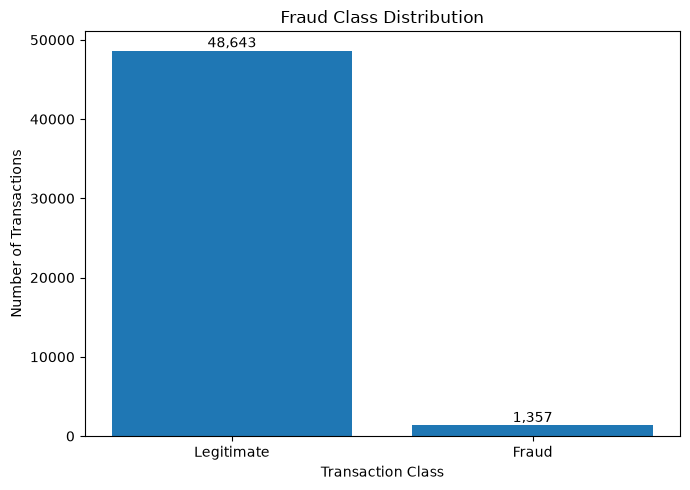

In [8]:
fraud_counts = transaction_df["isFraud"].value_counts().sort_index()

labels = ["Legitimate", "Fraud"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, fraud_counts.values)

plt.title("Fraud Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for bar, count in zip(bars, fraud_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [9]:
missing_summary = (
    transaction_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_percentage"]

missing_summary.head(20)

,column,missing_percentage
0,D7,95.288
1,dist2,93.290
2,D13,92.644
3,D12,91.806
4,D14,91.344
5,D6,90.350
6,D9,82.500
7,D8,82.500
8,M7,81.552
9,M8,81.552


In [10]:
print(
    "Columns with more than 50% missing values:",
    (missing_summary["missing_percentage"] > 50).sum(),
)

print(
    "Columns with more than 90% missing values:",
    (missing_summary["missing_percentage"] > 90).sum(),
)

Columns with more than 50% missing values: 192
Columns with more than 90% missing values: 6


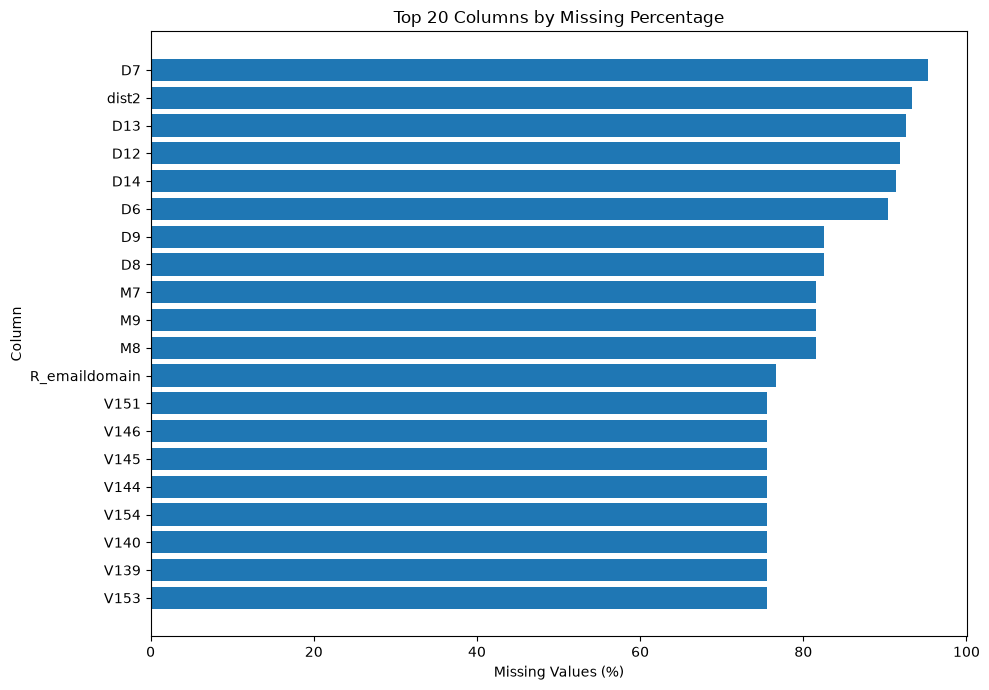

In [11]:
top_missing = missing_summary.head(20).sort_values(
    "missing_percentage"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_missing["column"],
    top_missing["missing_percentage"],
)

plt.title("Top 20 Columns by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

In [12]:
dtype_summary = (
    transaction_df.dtypes
    .astype(str)
    .value_counts()
)

dtype_summary

float64    376
str         14
int64        4
Name: count, dtype: int64

In [13]:
categorical_columns = transaction_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = transaction_df.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:", len(categorical_columns))
print("Numerical columns:", len(numerical_columns))

print("\nCategorical column names:")
print(categorical_columns)

Categorical columns: 14
Numerical columns: 380

Categorical column names:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


C:\Users\rakhi\AppData\Local\Temp\ipykernel_21592\1894001059.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = transaction_df.select_dtypes(


In [14]:
transaction_df["TransactionAmt"].describe()

count    50000.000000
mean       128.123213
std        213.075166
min          0.292000
25%         42.000000
50%         68.500000
75%        120.000000
max       4829.950000
Name: TransactionAmt, dtype: float64

C:\Users\rakhi\AppData\Local\Temp\ipykernel_21592\1385532256.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  transaction_df["TransactionAmtLog"] = np.log1p(


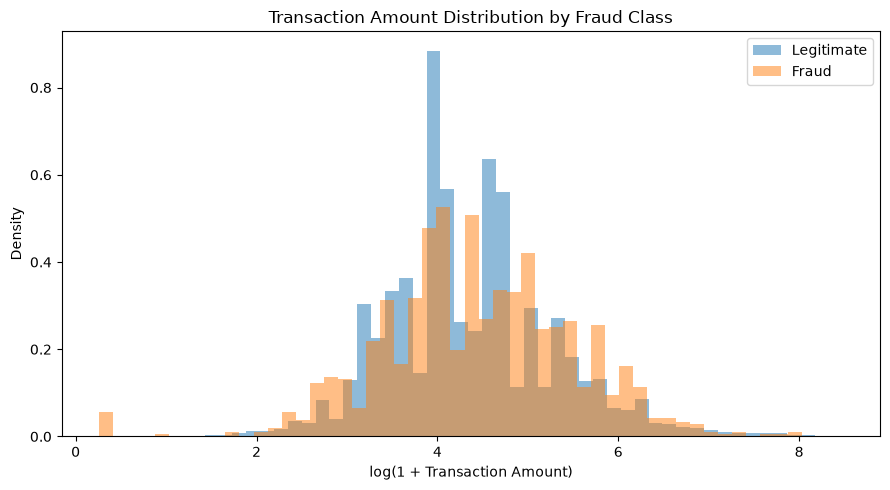

In [15]:
transaction_df["TransactionAmtLog"] = np.log1p(
    transaction_df["TransactionAmt"]
)

plt.figure(figsize=(9, 5))

for fraud_value, label in [
    (0, "Legitimate"),
    (1, "Fraud"),
]:
    subset = transaction_df.loc[
        transaction_df["isFraud"] == fraud_value,
        "TransactionAmtLog",
    ]

    plt.hist(
        subset,
        bins=50,
        alpha=0.5,
        label=label,
        density=True,
    )

plt.title("Transaction Amount Distribution by Fraud Class")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
full_target = pd.read_csv(
    TRANSACTION_PATH,
    usecols=["isFraud"],
)

full_fraud_summary = pd.DataFrame({
    "count": full_target["isFraud"].value_counts(),
    "percentage": (
        full_target["isFraud"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ),
})

full_fraud_summary.index = ["Legitimate", "Fraud"]

full_fraud_summary

,count,percentage
Legitimate,569877,96.5
Fraud,20663,3.5


In [17]:
categorical_columns = transaction_df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

In [18]:
transaction_df["TransactionAmtLog"] = np.log1p(
    transaction_df["TransactionAmt"]
)

In [19]:
transaction_amount_log = np.log1p(
    transaction_df["TransactionAmt"]
)

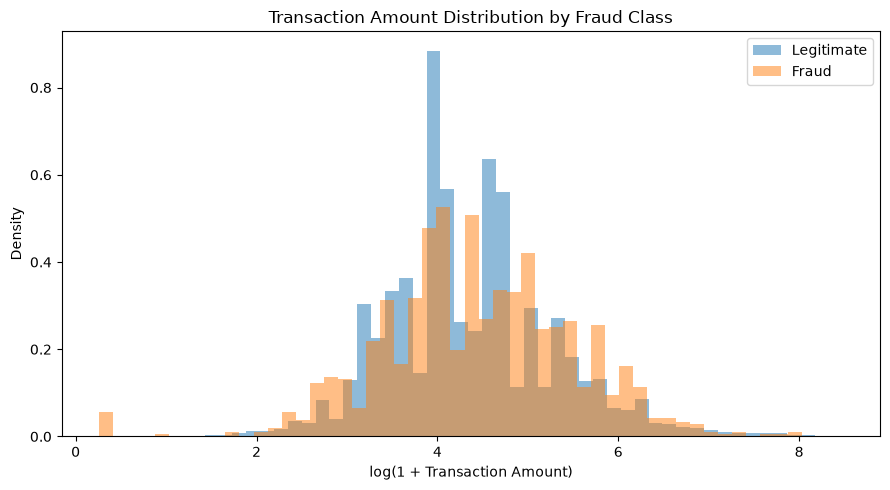

In [20]:
plt.figure(figsize=(9, 5))

for fraud_value, label in [
    (0, "Legitimate"),
    (1, "Fraud"),
]:
    subset = transaction_amount_log[
        transaction_df["isFraud"] == fraud_value
    ]

    plt.hist(
        subset,
        bins=50,
        alpha=0.5,
        label=label,
        density=True,
    )

plt.title("Transaction Amount Distribution by Fraud Class")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Initial Findings

- The complete training dataset contains 590,540 transactions.
- Fraud accounts for approximately 3.5% of all transactions.
- The target variable is highly imbalanced.
- The first 50,000 transactions have a lower fraud rate than the full dataset.
- 192 transaction features contain more than 50% missing values.
- Six features contain more than 90% missing values.
- Transaction amount alone does not clearly separate fraudulent and legitimate transactions.
- Precision, recall, PR-AUC and business cost will be more useful than accuracy.

## Identity Dataset Integration

In [21]:
merged_df = transaction_df.merge(
    identity_df,
    on="TransactionID",
    how="left",
    validate="one_to_one",
)

print("Transaction sample shape:", transaction_df.shape)
print("Identity dataset shape:", identity_df.shape)
print("Merged sample shape:", merged_df.shape)

Transaction sample shape: (50000, 395)
Identity dataset shape: (144233, 41)
Merged sample shape: (50000, 435)


In [22]:
identity_columns = [
    column
    for column in identity_df.columns
    if column != "TransactionID"
]

has_identity_information = (
    merged_df[identity_columns]
    .notna()
    .any(axis=1)
)

identity_coverage = (
    has_identity_information
    .mean()
    * 100
)

print(
    f"Transactions with identity information: "
    f"{identity_coverage:.2f}%"
)

Transactions with identity information: 32.91%


In [23]:
identity_fraud_summary = (
    merged_df.assign(
        has_identity=has_identity_information
    )
    .groupby("has_identity")["isFraud"]
    .agg(
        transaction_count="size",
        fraud_count="sum",
        fraud_rate="mean",
    )
)

identity_fraud_summary["fraud_rate_percent"] = (
    identity_fraud_summary["fraud_rate"] * 100
)

identity_fraud_summary

C:\Users\rakhi\AppData\Local\Temp\ipykernel_21592\580238040.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df.assign(


,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
has_identity,,,,
False,33544,693,0.020659,2.065943
True,16456,664,0.040350,4.035002


In [24]:
product_fraud_summary = (
    transaction_df.groupby("ProductCD")["isFraud"]
    .agg(
        transaction_count="size",
        fraud_count="sum",
        fraud_rate="mean",
    )
)

product_fraud_summary["fraud_rate_percent"] = (
    product_fraud_summary["fraud_rate"] * 100
)

product_fraud_summary.sort_values(
    "fraud_rate_percent",
    ascending=False,
)

,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
ProductCD,,,,
C,4934,497,0.100730,10.072963
R,3354,76,0.022660,2.265951
S,1464,29,0.019809,1.980874
W,32798,633,0.019300,1.929996
H,7450,122,0.016376,1.637584


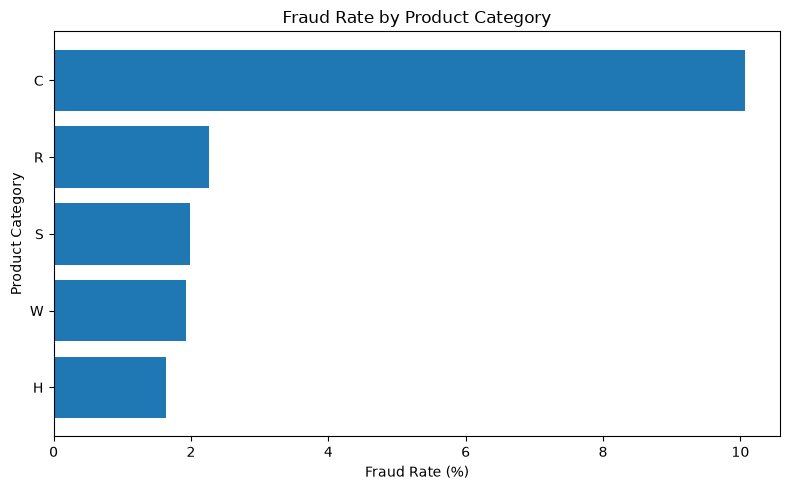

In [25]:
product_plot_data = (
    product_fraud_summary
    .sort_values("fraud_rate_percent")
)

plt.figure(figsize=(8, 5))

plt.barh(
    product_plot_data.index,
    product_plot_data["fraud_rate_percent"],
)

plt.title("Fraud Rate by Product Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [26]:
transaction_hour = (
    transaction_df["TransactionDT"] // 3600
) % 24

In [27]:
hourly_fraud_summary = (
    pd.DataFrame({
        "transaction_hour": transaction_hour,
        "isFraud": transaction_df["isFraud"],
    })
    .groupby("transaction_hour")["isFraud"]
    .agg(
        transaction_count="size",
        fraud_count="sum",
        fraud_rate="mean",
    )
)

hourly_fraud_summary["fraud_rate_percent"] = (
    hourly_fraud_summary["fraud_rate"] * 100
)

hourly_fraud_summary.head()

,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
transaction_hour,,,,
0,3294,91,0.027626,2.762599
1,2938,81,0.027570,2.756978
2,2376,56,0.023569,2.356902
3,1888,61,0.032309,3.230932
4,1326,37,0.027903,2.790347


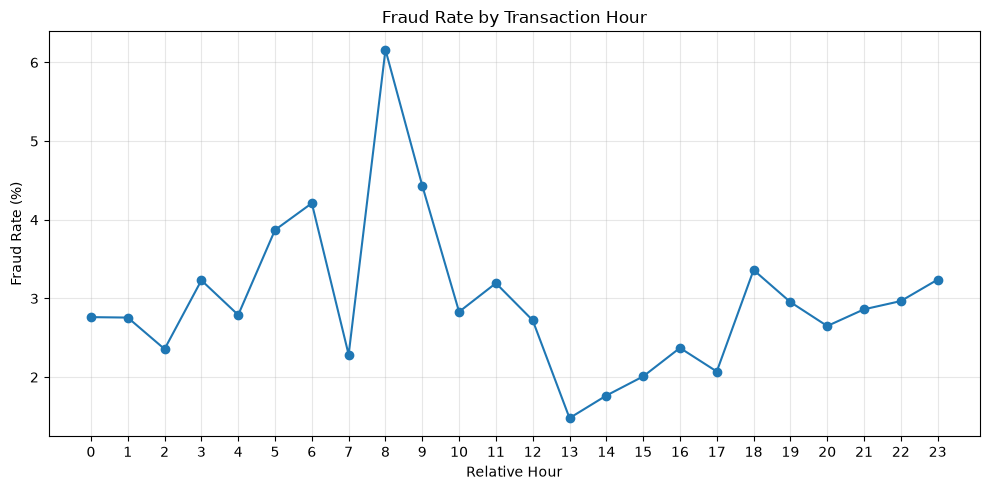

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_fraud_summary.index,
    hourly_fraud_summary["fraud_rate_percent"],
    marker="o",
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Relative Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()